# Knowledge Gap Detection Using Advanced Clustering Analytics

This notebook builds an end-to-end **Knowledge Gap Detection** workflow using clustering and then creates a **web interface** with Streamlit.

## What you will do
1. Create or load learner performance data
2. Cluster learners by topic performance
3. Detect topic-level knowledge gaps per cluster
4. Add confidence and distance-based diagnostics
5. Build a Streamlit web app for interactive predictions and action plans

In [1]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn streamlit joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('Libraries imported successfully.')

Libraries imported successfully.


## 1) Create Sample Student Performance Data

Each row is a learner and each feature is a topic score (0-100).

You can replace this generated data with your real dataset later.

In [3]:
n_students = 300

# Simulated topic scores
algebra = np.clip(np.random.normal(68, 15, n_students), 20, 100)
geometry = np.clip(np.random.normal(62, 18, n_students), 15, 100)
statistics = np.clip(np.random.normal(58, 20, n_students), 10, 100)
programming = np.clip(np.random.normal(65, 17, n_students), 15, 100)
problem_solving = np.clip(np.random.normal(60, 16, n_students), 10, 100)

df = pd.DataFrame({
    'Student_ID': [f'STU_{i:03d}' for i in range(1, n_students + 1)],
    'Algebra': algebra.round(1),
    'Geometry': geometry.round(1),
    'Statistics': statistics.round(1),
    'Programming': programming.round(1),
    'Problem_Solving': problem_solving.round(1)
})

df.head()

,Student_ID,Algebra,Geometry,Statistics,Programming,Problem_Solving
0,STU_001,75.5,47.1,73.1,71.3,62.0
1,STU_002,65.9,51.9,39.6,58.3,53.1
2,STU_003,77.7,75.5,75.4,65.5,62.0
3,STU_004,90.8,73.0,85.1,86.7,68.7
4,STU_005,64.5,61.6,66.3,68.2,60.8


## 2) Preprocess and Find Best Number of Clusters

We use silhouette score to choose the best number of clusters.

In [4]:
features = ['Algebra', 'Geometry', 'Statistics', 'Programming', 'Problem_Solving']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(2, 8)
scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

best_k = k_values[np.argmax(scores)]
print(f'Best k based on silhouette score: {best_k}')

  File "c:\Users\sanjai ram\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\sanjai ram\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\sanjai ram\miniconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sanjai ram\miniconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umas

Best k based on silhouette score: 7


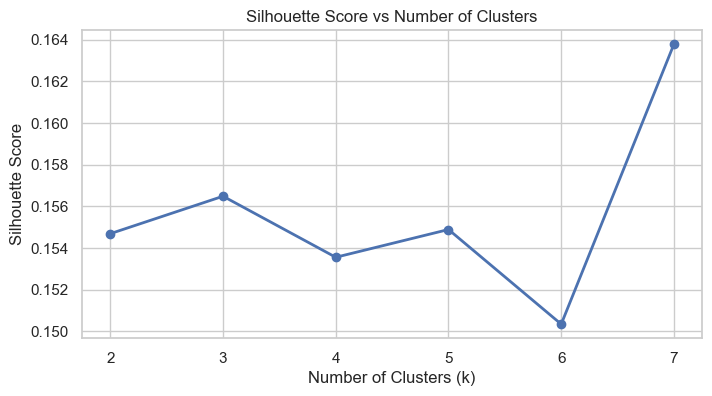

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), scores, marker='o', linewidth=2)
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.show()

## 3) Train Final Clustering Model

In [5]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_sizes = df['Cluster'].value_counts().sort_index()
display(cluster_sizes)

df.head()

Cluster
0    41
1    43
2    48
3    47
4    52
5    37
6    32
Name: count, dtype: int64

,Student_ID,Algebra,Geometry,Statistics,Programming,Problem_Solving,Cluster
0,STU_001,75.5,47.1,73.1,71.3,62.0,4
1,STU_002,65.9,51.9,39.6,58.3,53.1,2
2,STU_003,77.7,75.5,75.4,65.5,62.0,4
3,STU_004,90.8,73.0,85.1,86.7,68.7,4
4,STU_005,64.5,61.6,66.3,68.2,60.8,4


## 4) Detect Knowledge Gaps by Cluster

A topic is marked as a gap if average score for that cluster is below threshold.

In [6]:
gap_threshold = 60

cluster_profiles = df.groupby('Cluster')[features].mean().round(2)
cluster_profiles

,Algebra,Geometry,Statistics,Programming,Problem_Solving
Cluster,,,,,
0,83.42,57.29,41.31,75.17,68.62
1,77.21,77.87,55.41,76.81,49.07
2,62.73,49.71,46.03,59.51,50.72
3,58.47,77.81,65.00,47.18,56.88
4,73.62,54.86,82.51,71.48,62.93
5,65.70,51.96,59.78,57.82,86.43
6,49.19,60.81,62.66,83.18,60.46


In [7]:
cluster_gaps = {}
for c in cluster_profiles.index:
    weak_topics = cluster_profiles.loc[c][cluster_profiles.loc[c] < gap_threshold].index.tolist()
    cluster_gaps[int(c)] = weak_topics

cluster_gaps

{0: ['Geometry', 'Statistics'],
 1: ['Statistics', 'Problem_Solving'],
 2: ['Geometry', 'Statistics', 'Programming', 'Problem_Solving'],
 3: ['Algebra', 'Programming', 'Problem_Solving'],
 4: ['Geometry'],
 5: ['Geometry', 'Statistics', 'Programming'],
 6: ['Algebra']}

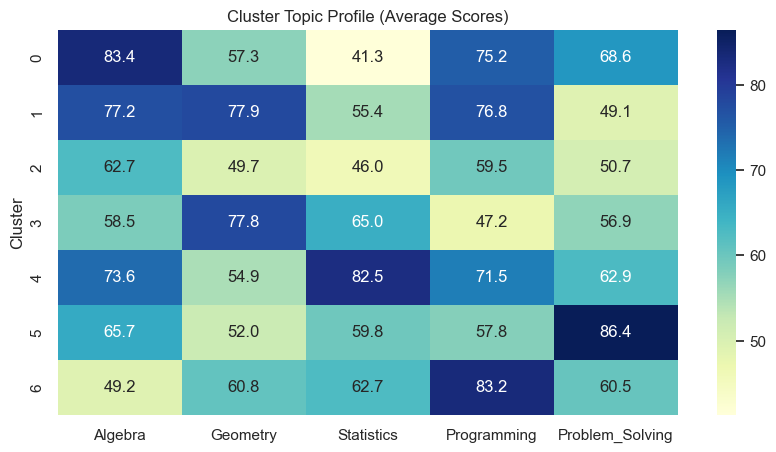

In [9]:
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Cluster Topic Profile (Average Scores)')
plt.show()

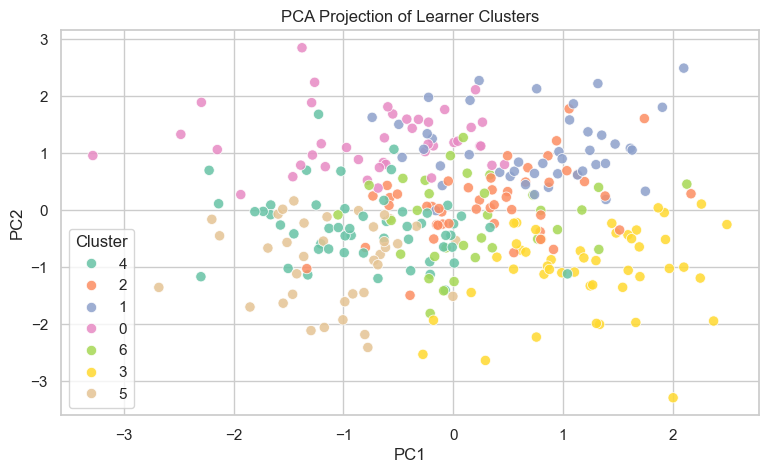

,mean,std
Cluster,,
0,1.5760,0.4979
1,1.5270,0.5202
2,1.4565,0.5013
3,1.6348,0.6319
4,1.4405,0.5756
5,1.5627,0.4698
6,1.5283,0.4279


,Algebra,Geometry,Statistics,Programming,Problem_Solving
Cluster,,,,,
0,91.4,65.3,49.3,83.2,76.6
1,85.2,85.9,63.4,84.8,57.1
2,70.7,57.7,54.0,67.5,58.7
3,66.5,85.8,73.0,55.2,64.9
4,81.6,62.9,90.5,79.5,70.9
5,73.7,60.0,67.8,65.8,94.4
6,57.2,68.8,70.7,91.2,68.5


Statistics         0.2212
Problem_Solving    0.2105
Geometry           0.2100
Programming        0.1824
Algebra            0.1760
Name: Priority_Weight, dtype: float64

In [8]:
# PCA projection for visual inspection of cluster separation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df['Cluster'].astype(str)
})

plt.figure(figsize=(9, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=55, alpha=0.85)
plt.title('PCA Projection of Learner Clusters')
plt.show()

# Distance to assigned centroid is used later for confidence scoring
distance_matrix = kmeans.transform(X_scaled)
df['Distance_To_Centroid'] = distance_matrix[np.arange(len(df)), df['Cluster']]

cluster_distance_stats = (
    df.groupby('Cluster')['Distance_To_Centroid']
      .agg(['mean', 'std'])
      .fillna(0)
      .round(4)
)

topic_targets = (cluster_profiles + 8).clip(upper=100).round(1)

# Higher weight means the topic has larger overall difficulty in the cohort
topic_difficulty = (100 - df[features].mean()).round(2)
priority_weight_map = (topic_difficulty / topic_difficulty.sum()).round(4).to_dict()

remediation_map = {
    'Algebra': ['Linear equations drills', 'Timed simplification quizzes', 'Error-log review for signs and operations'],
    'Geometry': ['Diagram labeling practice', 'Theorem flashcards', 'Proof-by-steps worksheets'],
    'Statistics': ['Mean/median/variance mini-sets', 'Interpretation of charts', 'Probability micro-practice'],
    'Programming': ['Debugging exercises', 'Function decomposition tasks', 'Data-structure coding katas'],
    'Problem_Solving': ['Pattern-recognition puzzles', 'Multi-step word problems', 'Reflective solution journaling']
}

display(cluster_distance_stats)
display(topic_targets)
display(pd.Series(priority_weight_map, name='Priority_Weight').sort_values(ascending=False))

## 6) Save Model Artifacts

These files are used by the web interface, including advanced diagnostics.

In [9]:
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(features, 'features.pkl')
joblib.dump(cluster_profiles, 'cluster_profiles.pkl')
joblib.dump(cluster_gaps, 'cluster_gaps.pkl')
joblib.dump(cluster_distance_stats, 'cluster_distance_stats.pkl')
joblib.dump(topic_targets, 'topic_targets.pkl')
joblib.dump(priority_weight_map, 'priority_weight_map.pkl')
joblib.dump(remediation_map, 'remediation_map.pkl')

print('Artifacts saved: kmeans_model.pkl, scaler.pkl, features.pkl, cluster_profiles.pkl, cluster_gaps.pkl, cluster_distance_stats.pkl, topic_targets.pkl, priority_weight_map.pkl, remediation_map.pkl')

Artifacts saved: kmeans_model.pkl, scaler.pkl, features.pkl, cluster_profiles.pkl, cluster_gaps.pkl, cluster_distance_stats.pkl, topic_targets.pkl, priority_weight_map.pkl, remediation_map.pkl


## 7) Build Streamlit Web Interface

This cell writes a file named `app.py` in your workspace with confidence scoring, weighted risk analytics, and intervention planning.

In [11]:
app_code = '''
import streamlit as st
import numpy as np
import pandas as pd
import joblib

st.set_page_config(page_title='Knowledge Gap Detector - Expert', page_icon='📘', layout='wide')

kmeans = joblib.load('kmeans_model.pkl')
scaler = joblib.load('scaler.pkl')
features = joblib.load('features.pkl')
cluster_profiles = joblib.load('cluster_profiles.pkl')
cluster_gaps = joblib.load('cluster_gaps.pkl')
cluster_distance_stats = joblib.load('cluster_distance_stats.pkl')
topic_targets = joblib.load('topic_targets.pkl')
priority_weight_map = joblib.load('priority_weight_map.pkl')
remediation_map = joblib.load('remediation_map.pkl')

st.title('Expert Knowledge Gap Detection')
st.caption('Cluster prediction + confidence + weighted risk score + intervention planner')

with st.sidebar:
    st.header('Controls')
    gap_threshold = st.slider('Gap threshold', 40, 80, 60)
    confidence_floor = st.slider('Low confidence alert threshold', 0.20, 0.80, 0.45)
    action_horizon = st.selectbox('Action horizon', ['2 Weeks', '4 Weeks', '8 Weeks'], index=1)

left, right = st.columns([1, 1])

with left:
    st.subheader('Input Scores')
    algebra = st.slider('Algebra', 0, 100, 65)
    geometry = st.slider('Geometry', 0, 100, 60)
    statistics = st.slider('Statistics', 0, 100, 55)
    programming = st.slider('Programming', 0, 100, 70)
    problem_solving = st.slider('Problem Solving', 0, 100, 58)

    user_values = [algebra, geometry, statistics, programming, problem_solving]
    user_input = np.array([user_values])

if st.button('Analyze Learner Profile', use_container_width=True):
    user_scaled = scaler.transform(user_input)
    distances = kmeans.transform(user_scaled)[0]
    pred_cluster = int(np.argmin(distances))
    assigned_distance = float(distances[pred_cluster])
    confidence = float(1 - (assigned_distance / (distances.sum() + 1e-9)))
    confidence = float(np.clip(confidence, 0.0, 1.0))

    profile_row = cluster_profiles.loc[pred_cluster]
    target_row = topic_targets.loc[pred_cluster]

    gap_table = pd.DataFrame({
        'Topic': features,
        'Learner_Score': user_values,
        'Cluster_Average': [round(profile_row[f], 1) for f in features],
        'Suggested_Target': [round(target_row[f], 1) for f in features],
        'Priority_Weight': [float(priority_weight_map.get(f, 0.2)) for f in features]
    })

    gap_table['Gap_to_Target'] = (gap_table['Suggested_Target'] - gap_table['Learner_Score']).round(1)
    gap_table['Gap_to_Cluster_Avg'] = (gap_table['Cluster_Average'] - gap_table['Learner_Score']).round(1)
    gap_table['Weighted_Deficit'] = ((gap_table['Gap_to_Target'].clip(lower=0) / 100) * gap_table['Priority_Weight']).round(4)

    weak_topics = gap_table.loc[gap_table['Learner_Score'] < gap_threshold, 'Topic'].tolist()

    def severity(v):
        if v >= 20:
            return 'High'
        if v >= 10:
            return 'Medium'
        if v > 0:
            return 'Low'
        return 'On Track'

    gap_table['Severity'] = gap_table['Gap_to_Target'].apply(severity)
    gap_table['Priority_Rank'] = gap_table['Weighted_Deficit'].rank(ascending=False, method='dense').astype(int)

    risk_score = float(np.clip(gap_table['Weighted_Deficit'].sum() * 100, 0, 100))
    if risk_score >= 35:
        risk_tier = 'Critical'
        weekly_intensity = '5 focused sessions / week'
    elif risk_score >= 22:
        risk_tier = 'High'
        weekly_intensity = '4 focused sessions / week'
    elif risk_score >= 10:
        risk_tier = 'Moderate'
        weekly_intensity = '3 focused sessions / week'
    else:
        risk_tier = 'Low'
        weekly_intensity = '2 maintenance sessions / week'

    with right:
        st.subheader('Prediction Summary')
        st.success(f'Predicted Learner Cluster: {pred_cluster}')
        st.write(f'Centroid distance: **{assigned_distance:.3f}**')

        st.write('Confidence')
        st.progress(confidence)
        st.write(f'Confidence score: **{confidence:.2%}**')
        if confidence < confidence_floor:
            st.warning('Prediction confidence is low. Collect more evidence before intervention decisions.')

        baseline_mean = float(cluster_distance_stats.loc[pred_cluster, 'mean'])
        baseline_std = float(cluster_distance_stats.loc[pred_cluster, 'std'])
        st.caption(f'Cluster baseline centroid distance: mean={baseline_mean:.3f}, std={baseline_std:.3f}')

        st.metric('Weighted Risk Score', f'{risk_score:.1f}/100')
        st.metric('Risk Tier', risk_tier)

    tabs = st.tabs(['Gap Analysis', 'Topic Comparison', 'Intervention Planner', 'Export'])

    with tabs[0]:
        st.subheader('Gap Analysis Table')
        st.dataframe(gap_table.sort_values('Priority_Rank'), use_container_width=True)

    with tabs[1]:
        compare_df = pd.DataFrame({
            'Topic': features,
            'Learner': user_values,
            'Cluster Average': [profile_row[f] for f in features],
            'Suggested Target': [target_row[f] for f in features]
        }).set_index('Topic')
        st.subheader('Topic Score Comparison')
        st.line_chart(compare_df)

    with tabs[2]:
        st.subheader('Personalized Intervention Planner')
        st.write(f'**Recommended cadence:** {weekly_intensity} for **{action_horizon}**')

        prioritized = gap_table.sort_values('Weighted_Deficit', ascending=False)
        for _, row in prioritized.iterrows():
            if row['Gap_to_Target'] <= 0:
                continue
            topic = row['Topic']
            st.markdown(f"**{topic}** | Severity: {row['Severity']} | Priority Rank: {int(row['Priority_Rank'])}")
            suggestions = remediation_map.get(topic, ['Focused revision and deliberate practice'])
            for item in suggestions:
                st.write(f'- {item}')

        if prioritized['Gap_to_Target'].max() <= 0:
            st.info('No major gaps found. Continue balanced practice and periodic assessments.')

    with tabs[3]:
        export_df = gap_table.sort_values('Priority_Rank').copy()
        csv_bytes = export_df.to_csv(index=False).encode('utf-8')
        st.download_button(
            label='Download Gap Report (CSV)',
            data=csv_bytes,
            file_name='knowledge_gap_report.csv',
            mime='text/csv'
        )
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print('Expert Streamlit app created: app.py')

Expert Streamlit app created: app.py
